<a href="https://colab.research.google.com/github/manuelagutierrezss16/Integraci-n-de-Datos-y-Prospectiva/blob/main/Manuela_Guti%C3%A9rrez_1_Caracterizaci%C3%B3n_de_Variables_Aleatorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Caso de Estudio**

• AutoRiesgo S.A. es una compañía especializada en el otorgamiento de créditos vehiculares para flotas comerciales.


• La empresa busca desarrollar un modelo estadístico de gestión de riesgos operacionales y de mora para estimar el impacto financiero de los vehículos colisionados o en impago, permitiéndole proyectar reservas de capital e integrar estrategias de mitigación.

Las  variables que serán utilizadas para este proceso son las siguientes:

*    Frecuencia ($N$): Número de créditos en mora con siniestro por semana (eventos/semana).  
*   Severidad ($S$): Costo promedio de liquidación/recuperación por cada vehículo (USD/evento).
* Distribución pérdidas ($\text{LDA} = N \times S$): Impacto financiero semanal en USD.  




### 0. Instalación y carga de librerías de trabajo

In [ ]:
import numpy as np
import pandas as pd #Leer archivos
import matplotlib.pyplot as plt #Graficar
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # los warningss existen porque la tabla no es del mismo tamaño toda

### 1. Generación y carga de los datos de trabajo

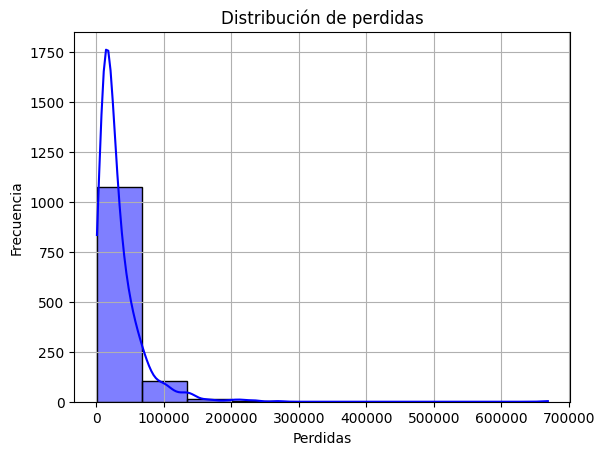

In [ ]:
np.random.seed(42)  # Semilla para reproducibilidad
n_samples = 1200    # Cumple con el requisito de más de 1000 datos

# Frecuencia (Número de eventos de riesgo por semana)
# Severidad (Costo promedio por evento en USD)
Frecuencia = np.random.poisson(lam=12, size=n_samples) + 1  # Evitar ceros
Severidad = np.random.lognormal(mean=7.5, sigma=0.8, size=n_samples)

# Creación de DataFrame principal
XDB = pd.DataFrame({
    'ID_Semana': np.arange(1, n_samples + 1),
    'Frecuencia': Frecuencia,
    'Severidad': Severidad
    })
LDA=XDB['Frecuencia']*XDB['Severidad']

# Se grafica
plt.figure()
sns.histplot(LDA,color='blue',bins=10,kde=True)
plt.title('Distribución de perdidas')
plt.xlabel('Perdidas')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()


### 2. Construcción del histograma de frecuencias

In [ ]:
NI = 10  # Número de Intervalos
counts, Limits = np.histogram(LDA, bins=NI)

LI = Limits[:-1]            # Límites inferiores
LS = Limits[1:]             # Límites superiores
fi = counts / sum(counts)   # Frecuencia relativa (porcentaje)
MC = (LI + LS) / 2          # Marca de clase

# DataFrame resumen del histograma
df_hist = pd.DataFrame(np.column_stack((LI, LS, counts, fi, MC)))
df_hist.columns = ["LI", "LS", "ND", "fi", "MC"]
print("--- TABLA DE FRECUENCIAS DE LA LDA ---")
display(df_hist)

--- TABLA DE FRECUENCIAS DE LA LDA ---


,LI,LS,ND,fi,MC
0,1156.324099,67943.337521,1076.0,0.896667,34549.830810
1,67943.337521,134730.350943,102.0,0.085000,101336.844232
2,134730.350943,201517.364366,15.0,0.012500,168123.857655
3,201517.364366,268304.377788,5.0,0.004167,234910.871077
4,268304.377788,335091.391210,1.0,0.000833,301697.884499
5,335091.391210,401878.404632,0.0,0.000000,368484.897921
6,401878.404632,468665.418055,0.0,0.000000,435271.911344
7,468665.418055,535452.431477,0.0,0.000000,502058.924766
8,535452.431477,602239.444899,0.0,0.000000,568845.938188
9,602239.444899,669026.458321,1.0,0.000833,635632.951610


### 3. Medidas de tendencia central

In [ ]:
#1 Media: Valor esperado de una pérdida (¿Qué es lo más común que pase?)
u= np.sum(MC*fi)
print("La media es: ",u)

#2 Varianza: Indica que tan dispersos están los datos al reddedor de la Media
varc=np.sum(((MC-u)**2)*fi)
print("la varianza es:", varc)

#3 La desviación: raiz cuadrada de la varianza
sigma=np.sqrt(varc)
print("la desviación es: ", sigma)

#4 Intervalo de variación de las perdidas
print("El límite inferior es:", u-2*sigma) # se multiplica *2 por el intervalo de confianza, en 2 sigmas se encuentra el 95% de los datos,
print("El liite superior es:", u+2*sigma)#  si solo fuera 1 se encuentra el 68% de los datos

#5 coeficiente de asimetria
cas=np.sum(((MC-u)**3)*fi)/((sigma**3))
print("El coeficiente de asimetría es:", cas)

#6 Coeficiente de curtosis
cur = np.sum(((MC - u)**4) * fi) / (sigma**4) - 3
print("El coeficiente de curtosis es:", cur)


La media es:  43454.76593302578
la varianza es: 1050696771.461432
la desviación es:  32414.45312605832
El límite inferior es: -21374.14031909086
El liite superior es: 108283.67218514242
El coeficiente de asimetría es: 7.537660946684311
El coeficiente de curtosis es: 101.85982556069776


###**ANALISIS DE RESULTADOS**

MEDIA: Punto medio o promedio
* El impacto combinado de los siniestros y la mora le cuesta a la organización unos 43,454.77 USD. (Este número nos indica cuál debe ser el fondo básico o presupuesto que el área de finanzas debe reservar por defecto para cubrir los riesgos diarios del negocio.)

VARIANZA: distancia
DESVIACION ESTANDAR: distancia en la unidad del dato (dinero, peso...)
ambas miden la distancia entre los datos y el promedio
* Al comparar los 32,414(DS) con los 43,454(M), vemos que la variabilidad es de casi el 75%.(Esto demuestra que el riesgo operativo no es estable. La gerencia no puede asumir que todas las semanas perderá 43k; habrá semanas muy buenas y semanas financieramente muy duras.)

LIMITE SUPERIOR:
* Sumar la media más dos desviaciones estándar nos da 108,283.67 USD.( La empresa sabe que el 95% de las semanas malas las responderá adecuadamente si tiene un fondo de liquidez de 108,000 USD disponible.)

COEFICIENTE DE ASIMETRIA: que tan juntos o inclinados hacia los lados estan los datos del promedio (asimetria 0, a+ mayor a 0 y va a la izquierda)
* La Asimetría (7.54) nos confirma que la mayoría de los eventos son siniestros pequeños (ej. choques menores, retrasos de pocos días).

COEFICIENTE DE CURTOSIS: que tan puntiaguda es la grafica y que tan grusas son sus colas,( frecuencia de atipicos)(cercana a 0 o 3 pocos eventos atipicos, mayor a 10 eventos atipicos con frecuencia)
* existen eventos extremos de muy alto costo (ej. la pérdida total de una flota entera o el impago masivo de un gran cliente), por esto se le recomienda a la empreza tener seguros para proteger la empreza.

### **CASO DE ESTUDIO COMPLETO**

**Caso de Estudio** Gestión de Riesgo Operacional y de Crédito AutoRiesgo S.A.

**Objetivos del Negocio**
• AutoRiesgo S.A. es una compañía especializada en el otorgamiento de créditos vehiculares para flotas comerciales.
• La empresa busca desarrollar un modelo estadístico de gestión de riesgos operacionales y de mora para estimar el impacto financiero de los vehículos colisionados o en impago, permitiéndole proyectar reservas de capital e integrar estrategias de mitigación.

**Abstracción**
• Los eventos de riesgo con mayor impacto económico están asociados al impago de créditos combinado con el costo de recuperación o siniestralidad de los vehículos.
• Para ello, se requiere construir la Distribución Agregada de Pérdidas (LDA) combinando la Frecuencia (mora/siniestros semanales) y la Severidad (costo promedio por evento).

 **Técnicas a utilizar**
 • Análisis Exploratorio de Datos (EDA): Tablas de frecuencia, marcas de clase e histogramas.
 • Estadística Descriptiva: Cálculo de métricas de tendencia central (media) y dispersión (varianza, desviación estándar, asimetría y curtosis).

 **Variables del Modelo**
 • Frecuencia ($N$): Número de créditos en mora con siniestro por semana (eventos/semana).
  • Severidad ($S$): Costo promedio de liquidación/recuperación por cada vehículo (USD/evento).
   • Pérdida Agregada ($\text{LDA} = N \times S$): Impacto financiero semanal en USD.  